In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

In [94]:
df = pd.read_csv("../../data/NF-UNSW-NB15-v3.csv")

In [107]:
df.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,...,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2,...,0,0,0,0,0,0,0,0,0,Benign


In [130]:
benign_sample = df[df['Label'] == 0].sample(n=30000, random_state=42)

malicious_sample = df[df['Label'] == 1].sample(n=30000, random_state=42)

In [131]:
df_sampled = pd.concat([benign_sample, malicious_sample]).reset_index(drop=True)

print(df_sampled['Label'].value_counts())

Label
0    30000
1    30000
Name: count, dtype: int64


In [132]:
drop_cols = [
    'Attack', 'Label', 'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 
    'L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO'
]

In [133]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)

X = X.dropna()
y = y.loc[X.index]

In [134]:
X = X.select_dtypes(include=['int64','float64'])
print("Number of features:", X.shape[1])

Number of features: 47


In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

print(X_train.shape, X_test.shape)

(13455, 47) (3364, 47)


## K-NN

In [136]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [137]:
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      1922
           1       0.81      0.92      0.86      1442

    accuracy                           0.87      3364
   macro avg       0.87      0.87      0.87      3364
weighted avg       0.88      0.87      0.87      3364



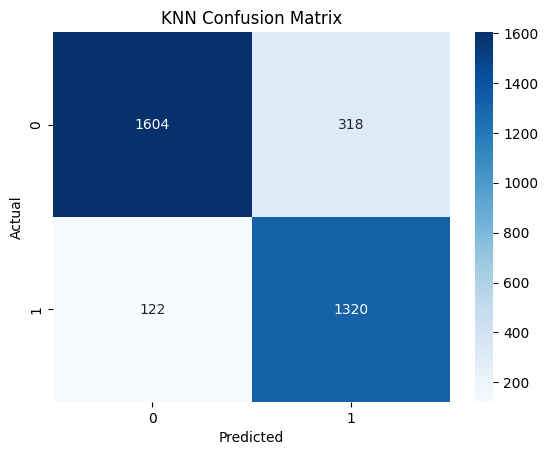

In [129]:
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

## This is an example of over fitting

The model cannot make any predictions on the provided data

In [127]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1922
           1       1.00      1.00      1.00      1442

    accuracy                           1.00      3364
   macro avg       1.00      1.00      1.00      3364
weighted avg       1.00      1.00      1.00      3364

